In [ ]:
# import transformers
# print(transformers.__version__)

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("news_with_bias_and_fake_labels_10062025.csv", encoding='latin-1')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5544 entries, 0 to 5543
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          5544 non-null   object 
 1   title              5544 non-null   object 
 2   summary            5497 non-null   object 
 3   link               5544 non-null   object 
 4   source             5544 non-null   object 
 5   text               5544 non-null   object 
 6   datetime           5544 non-null   object 
 7   title_clean        5544 non-null   object 
 8   summary_clean      5496 non-null   object 
 9   entities           5544 non-null   object 
 10  entity_names       5544 non-null   object 
 11  entity_types       5544 non-null   object 
 12  keyphrases         5544 non-null   object 
 13  language           5544 non-null   object 
 14  translated_text    5544 non-null   object 
 15  text_for_analysis  5544 non-null   object 
 16  truth_prediction   5544 

In [ ]:
df.head(5)

,timestamp,title,summary,link,source,text,datetime,title_clean,summary_clean,entities,entity_names,entity_types,keyphrases,language,translated_text,text_for_analysis,truth_prediction,truth_confidence,bias_label,bias_confidence
0,2025-06-06T10:01:03.992296,Israeli army admits to Gaza strike after BBC V...,Israeli army admits to Gaza strike after BBC V...,https://www.bbc.com/news/articles/cr7zplv35l1o,bbc,Israeli army admits to Gaza strike after BBC V...,2025-06-06 10:01,Israeli army admits to Gaza strike after BBC V...,Israeli army admits to Gaza strike after BBC V...,"[('Khan Younis', 'PERSON'), ('Israeli', 'NORP'...","['Khan Younis', 'Israeli', 'Palestinian', 'Gaz...","['PERSON', 'NORP', 'NORP', 'GPE', 'DATE', 'ORG']","['strike', 'israeli', 'admits gaza', 'army adm...",en,Israeli army admits to Gaza strike after BBC V...,Israeli army admits to Gaza strike after BBC V...,real,0.785213,neutral,0.099077
1,2025-06-06T10:01:03.992296,How bitter feud escalated - and what happens n...,How bitter feud escalated - and what happens n...,https://www.bbc.com/news/articles/c3wd2215q08o,bbc,How bitter feud escalated - and what happens n...,2025-06-06 10:01,How bitter feud escalated - and what happens n...,How bitter feud escalated - and what happens n...,"[('Canada', 'GPE')]",['Canada'],['GPE'],"['nexta', 'knock fight', 'powerful politician'...",en,How bitter feud escalated - and what happens n...,How bitter feud escalated - and what happens n...,real,0.893547,neutral,0.045673
2,2025-06-06T10:01:03.992296,Measles holiday warning as cases rise in Europ...,Measles holiday warning as cases rise in Europ...,https://www.bbc.com/news/articles/c706y4jr95lo,bbc,Measles holiday warning as cases rise in Europ...,2025-06-06 10:01,Measles holiday warning as cases rise in Europ...,Measles holiday warning as cases rise in Europ...,"[('the summer holiday season', 'DATE'), ('UK',...","['the summer holiday season', 'UK', 'European'...","['DATE', 'GPE', 'NORP', 'GPE', 'GPE']","['measles', 'holiday', 'summer holiday', 'holi...",en,Measles holiday warning as cases rise in Europ...,Measles holiday warning as cases rise in Europ...,real,0.843587,neutral,0.088941
3,2025-06-06T10:01:03.992296,Tesla shares tumble as Trump-Musk feud erupts1...,Tesla shares tumble as Trump-Musk feud erupts1...,https://www.bbc.com/news/articles/cy902rv7q8do,bbc,Tesla shares tumble as Trump-Musk feud erupts1...,2025-06-06 10:01,Tesla shares tumble as Trump-Musk feud erupts1...,Tesla shares tumble as Trump-Musk feud erupts1...,"[('agoBusiness', 'ORG'), ('Trump-Musk', 'PERSO...","['agoBusiness', 'Trump-Musk']","['ORG', 'PERSON']","['feud erupts16', 'erupts16 hrs', 'erupts16', ...",en,Tesla shares tumble as Trump-Musk feud erupts1...,Tesla shares tumble as Trump-Musk feud erupts1...,real,0.832165,right-wing,0.081489
4,2025-06-06T10:01:03.992296,Australian mushroom lunch cook tells trial mea...,Australian mushroom lunch cook tells trial mea...,https://www.bbc.com/news/articles/c5y8e1l55kko,bbc,Australian mushroom lunch cook tells trial mea...,2025-06-06 10:01,Australian mushroom lunch cook tells trial mea...,Australian mushroom lunch cook tells trial mea...,"[('Australian', 'NORP')]",['Australian'],['NORP'],"['special9', 'special9 hrs', 'meal special9', ...",en,Australian mushroom lunch cook tells trial mea...,Australian mushroom lunch cook tells trial mea...,real,0.840357,neutral,0.066446


In [ ]:
df.isnull().sum()

,0
timestamp,0
title,0
summary,47
link,0
source,0
text,0
datetime,0
title_clean,0
summary_clean,48
entities,0


In [ ]:
df['summary'] = df['summary'].fillna("")
df['summary_clean'] = df['summary_clean'].fillna("")

In [ ]:
from transformers import pipeline
!pip install bertopic
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

In [ ]:
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
sentiment_pipe = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

Device set to use cuda:0


In [ ]:
# Detect device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def get_sentiment(text):
    inputs = tokenizer(text, truncation=True, padding=True, return_tensors="pt", max_length=512)
    inputs = {key: val.to(device) for key, val in inputs.items()}  # Move input to model's device

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_class = logits.argmax().item()

    label_map = {
        0: "NEGATIVE",
        1: "NEUTRAL",
        2: "POSITIVE"
    }
    return label_map[predicted_class]

# Safely apply to your dataframe
df['sentiment'] = df['translated_text'].astype(str).apply(get_sentiment)

In [ ]:
print(df[['translated_text', 'sentiment']].head(5))

                                     translated_text sentiment
0  Israeli army admits to Gaza strike after BBC V...  NEGATIVE
1  How bitter feud escalated - and what happens n...  NEGATIVE
2  Measles holiday warning as cases rise in Europ...  NEGATIVE
3  Tesla shares tumble as Trump-Musk feud erupts1...  NEGATIVE
4  Australian mushroom lunch cook tells trial mea...   NEUTRAL


In [ ]:
print(df['sentiment'].value_counts())

sentiment
NEUTRAL     3059
POSITIVE    1420
NEGATIVE    1065
Name: count, dtype: int64


In [ ]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Create BERTopic instance
topic_model = BERTopic(embedding_model=embedding_model, verbose=True)

# Fit and transform using translated_text
topics, probs = topic_model.fit_transform(df['translated_text'])

# Save to DataFrame
df['topic'] = topics

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2025-06-10 15:44:26,181 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

2025-06-10 15:44:31,758 - BERTopic - Embedding - Completed ✓
2025-06-10 15:44:31,759 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-10 15:45:13,374 - BERTopic - Dimensionality - Completed ✓
2025-06-10 15:45:13,376 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-10 15:45:13,585 - BERTopic - Cluster - Completed ✓
2025-06-10 15:45:13,593 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-10 15:45:14,008 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2356,-1_and_the_to_of,"[and, the, to, of, in, for, with, is, that, on]",[I Accidentally Found This Samsung Trickand No...
1,0,141,0_shares_quarter_inc_stock,"[shares, quarter, inc, stock, companys, 000, d...",[California State Teachers Retirement System S...
2,1,124,1_security_cyber_compliance_cybersecurity,"[security, cyber, compliance, cybersecurity, h...",[Los Angeles Will Be Set Free! Trump Orders Fe...
3,2,97,2_nba_finals_pacers_thunder,"[nba, finals, pacers, thunder, game, sports, o...",[Thunder vs. Pacers How a small-market NBA Fin...
4,3,85,3_nvidia_nasdaqnvda_co_shares,"[nvidia, nasdaqnvda, co, shares, quarter, llc,...",[DSG Capital Advisors LLC Makes New 17.05 Mill...


In [ ]:
# Get all topic keywords from BERTopic
topic_keywords = topic_model.get_topics()

# Define simple keyword-category rules
category_keywords = {
    "Politics": ["government", "biden", "trump", "ukraine", "russia", "election", "nato", "israel", "gaza", "palestine", "war"],
    "Business": ["stock", "market", "shares", "quarter", "company", "revenue", "economy", "finance", "ceo"],
    "Health": ["vaccine", "covid", "cancer", "hospital", "health", "virus", "infection", "disease"],
    "Technology": ["ai", "robot", "tech", "cybersecurity", "device", "apple", "google", "cloud", "nvidia", "samsung"],
    "Sports": ["nba", "cricket", "match", "team", "goal", "game", "final", "score", "league"],
    "Education": ["student", "university", "school", "exam", "education", "college", "study"],
    "Environment": ["climate", "wildfire", "carbon", "pollution", "environment", "green", "heat"],
    "Astronomy": ["galaxy", "telescope", "space", "nasa", "astronomer", "planet"],
    "Gaming": ["nintendo", "playstation", "game", "mario", "switch"],
}

# Function to assign category based on topic words
def categorize_topic(topic_id):
    words = [word for word, _ in topic_keywords.get(topic_id, [])]
    for category, keywords in category_keywords.items():
        if any(keyword in words for keyword in keywords):
            return category
    return "Other"

# Apply to all topics
topic_id_to_category = {topic: categorize_topic(topic) for topic in topic_keywords.keys()}

# Map to your DataFrame
df['custom_topic'] = df['topic'].map(topic_id_to_category)

In [ ]:
print(df[['translated_text', 'topic', 'custom_topic']].head(10))

                                     translated_text  topic custom_topic
0  Israeli army admits to Gaza strike after BBC V...      5     Politics
1  How bitter feud escalated - and what happens n...      9     Politics
2  Measles holiday warning as cases rise in Europ...     86        Other
3  Tesla shares tumble as Trump-Musk feud erupts1...      9     Politics
4  Australian mushroom lunch cook tells trial mea...     -1        Other
5  We have a geriatric problem - Democrats wrestl...     -1        Other
6  Very disappointed and such ingratitude How Tru...      9     Politics
7  India leads in remittances - but Trumps tax co...     29        Other
8  Nato chief is determined to give Trump a win w...     23     Politics
9  Four arrested over India cricket stadium crush...     61       Sports


In [ ]:
print(df['custom_topic'].value_counts())

custom_topic
Other          3516
Business        554
Politics        488
Technology      382
Sports          280
Astronomy       113
Health           97
Environment      51
Education        34
Gaming           29
Name: count, dtype: int64


In [ ]:
df.to_csv("final_news_with_sentiment_and_topic.csv", index=False)

In [ ]:
topic_model.save("bertopic_model", save_embedding_model=True)

2025-06-09 16:54:53,203 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from datasets import Dataset

# Encode labels
label_map = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df['label'] = df['sentiment'].map(label_map)

# Split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['translated_text'], df['label'], test_size=0.2, random_state=42
)

# Convert to HF Datasets
train_ds = Dataset.from_dict({'text': train_texts, 'label': train_labels})
val_ds = Dataset.from_dict({'text': val_texts, 'label': val_labels})

# Tokenize
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=512)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)

Map:   0%|          | 0/4435 [00:00<?, ? examples/s]

Map:   0%|          | 0/1109 [00:00<?, ? examples/s]

In [ ]:
# !pip install -U --force-reinstall transformers

In [ ]:
from transformers import TrainingArguments, Trainer, EvalPrediction, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch # Import torch if not already imported

def compute_metrics(p: EvalPrediction):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

training_args = TrainingArguments(
    output_dir="./sentiment_finetuned",
    # Changed evaluation_strategy to eval_strategy to match current transformers library
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True
)

# Create a data collator that will dynamically pad the inputs to the longest length in a batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    # Add the data collator here
    data_collator=data_collator
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.301012,0.884581,0.886033,0.884581,0.884243
2,0.292600,0.450919,0.888188,0.889870,0.888188,0.888079
3,0.292600,0.556032,0.894500,0.894742,0.894500,0.894450


TrainOutput(global_step=834, training_loss=0.20554114874604223, metrics={'train_runtime': 1504.0702, 'train_samples_per_second': 8.846, 'train_steps_per_second': 0.554, 'total_flos': 3500724022871040.0, 'train_loss': 0.20554114874604223, 'epoch': 3.0})

In [ ]:
model.save_pretrained("sentiment_finetuned")
tokenizer.save_pretrained("sentiment_finetuned")

('sentiment_finetuned/tokenizer_config.json',
 'sentiment_finetuned/special_tokens_map.json',
 'sentiment_finetuned/vocab.json',
 'sentiment_finetuned/merges.txt',
 'sentiment_finetuned/added_tokens.json',
 'sentiment_finetuned/tokenizer.json')

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert custom_topic labels to numeric
label_encoder = LabelEncoder()
y_numeric = label_encoder.fit_transform(df['custom_topic'])

# Fit BERTopic with supervised labels
topic_model.fit(df['translated_text'].tolist(), y=y_numeric)

2025-06-10 16:38:29,425 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

2025-06-10 16:38:38,314 - BERTopic - Embedding - Completed ✓
2025-06-10 16:38:38,315 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-10 16:38:49,212 - BERTopic - Dimensionality - Completed ✓
2025-06-10 16:38:49,214 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-10 16:38:49,419 - BERTopic - Cluster - Completed ✓
2025-06-10 16:38:49,425 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-10 16:38:49,846 - BERTopic - Representation - Completed ✓


In [ ]:
# Get predicted topic IDs
predicted_topics, _ = topic_model.transform(df['translated_text'].tolist())

# Map topic_id to your predicted categories
topic_id_to_category = {topic: categorize_topic(topic) for topic in topic_model.get_topics().keys()}
predicted_labels = [topic_id_to_category.get(topic_id, "Other") for topic_id in predicted_topics]

# True labels (decoded from numeric)
true_labels = label_encoder.inverse_transform(y_numeric)

# Now compute evaluation metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(true_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average='weighted')

print("📊 BERTopic Evaluation:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Batches:   0%|          | 0/174 [00:00<?, ?it/s]

2025-06-10 16:39:25,453 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-06-10 16:39:25,500 - BERTopic - Dimensionality - Completed ✓
2025-06-10 16:39:25,505 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-06-10 16:39:25,966 - BERTopic - Cluster - Completed ✓


📊 BERTopic Evaluation:
Accuracy : 0.5469
Precision: 0.5808
Recall   : 0.5469
F1 Score : 0.5625


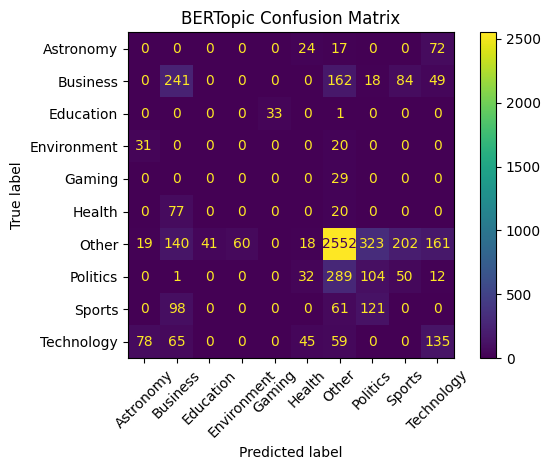

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(true_labels, predicted_labels, xticks_rotation=45)
plt.title("BERTopic Confusion Matrix")
plt.tight_layout()
plt.show()


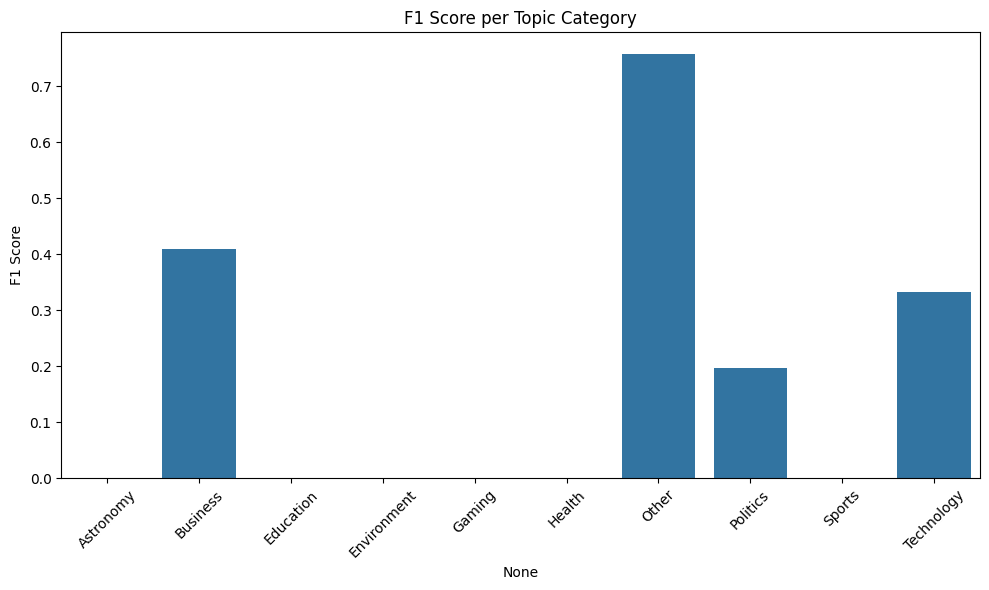

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Report
report = classification_report(true_labels, predicted_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Plot F1 scores
plt.figure(figsize=(10, 6))
sns.barplot(x=df_report.index[:-3], y=df_report['f1-score'][:-3])  # exclude avg rows
plt.xticks(rotation=45)
plt.title("F1 Score per Topic Category")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

In [ ]:
import pickle
# Save BERTopic model
with open("bertopic_model.pkl", "wb") as f:
    pickle.dump(topic_model, f)


In [ ]:
# Save model and tokenizer as .pkl
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump((model, tokenizer), f)


In [ ]:
import pkg_resources

required = {
    'transformers', 'torch', 'scikit-learn', 'sentence-transformers',
    'bertopic', 'umap-learn', 'hdbscan', 'pandas', 'numpy',
    'matplotlib', 'seaborn', 'tqdm'
}

installed = {pkg.key: pkg.version for pkg in pkg_resources.working_set}
with open("requirements.txt", "w") as f:
    for pkg in required:
        if pkg in installed:
            f.write(f"{pkg}=={installed[pkg]}\n")
